# E-Commerce Sales & Customer Revenue Analytics

## Project Overview

This project analyzes historical e-commerce transaction data to understand sales performance, customer purchasing behavior, product demand, and revenue trends.

The analysis uses Python and Pandas for data preparation and exploratory data analysis, followed by SQL-based business analysis and an interactive Power BI dashboard.


## Business Problem

E-commerce businesses need to understand their sales performance, customer purchasing behavior, and product demand in order to make informed decisions about revenue growth, customer retention, and product strategy.

This project uses historical transaction-level e-commerce data to identify sales trends, high-value customers, top-performing products, purchasing patterns, and other factors that influence overall revenue.


## Project Objectives

* Analyze overall sales and revenue performance.
* Identify monthly and yearly revenue trends.
* Identify the countries generating the highest revenue.
* Identify the top-performing products by sales and quantity.
* Analyze customer purchasing behavior and identify high-value customers.
* Analyze repeat purchasing patterns.
* Examine cancelled and returned transactions and their impact on sales.
* Generate actionable business recommendations based on the analysis.

## Tools & Technologies

* **Python** — Data analysis and preprocessing
* **Pandas** — Data manipulation and cleaning
* **Matplotlib** — Data visualization
* **Seaborn** — Exploratory data visualization
* **SQL** — Business-oriented data analysis
* **Power BI** — Interactive dashboard and reporting


## Dataset

The dataset contains historical transaction-level records from an online retail business. It covers transactions from two periods: 2009–2010 and 2010–2011.

The two sheets contain the same set of variables and will be combined into a single dataset before performing further analysis.

### Key Variables

| Column      | Description                           |
| ----------- | ------------------------------------- |
| Invoice     | Unique invoice/transaction identifier |
| StockCode   | Product or item identifier            |
| Description | Product description                   |
| Quantity    | Number of units purchased             |
| InvoiceDate | Date and time of the transaction      |
| Price       | Unit price of the product             |
| Customer ID | Customer identifier                   |
| Country     | Customer's country                    |

The combined dataset contains more than one million transaction records, providing sufficient data for analyzing sales, customer behavior, and product performance.


# 1. Data Loading & Initial Inspection

### Import Required Libraries

The following Python libraries will be used for data loading, manipulation, numerical analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Display all columns when working with the dataset
pd.set_option('display.max_columns', None)

### Load the Dataset

The dataset is stored in an Excel workbook containing two sheets representing transaction data for different periods.

Both sheets will be loaded separately first so that their structure, columns, and data types can be validated before combining them.


In [4]:
file_path = "../data/raw/online_retail_II.xlsx"

df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

### Check Dataset Dimensions

Before combining the two datasets, we check the number of rows and columns in each sheet.


In [5]:
print("2009-2010:", df_2009_2010.shape)
print("2010-2011:", df_2010_2011.shape)

2009-2010: (525461, 8)
2010-2011: (541910, 8)


In [6]:
print("2009-2010 columns:")
print(df_2009_2010.columns.tolist())

print("\n2010-2011 columns:")
print(df_2010_2011.columns.tolist())

2009-2010 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

2010-2011 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


### Check Data Types

Before combining the datasets, the data types of each column are checked to ensure that both sheets have compatible structures and that important fields such as dates, quantities, and prices are represented correctly.


In [7]:
print("2009-2010 Data Types:")
print(df_2009_2010.dtypes)

print("\n2010-2011 Data Types:")
print(df_2010_2011.dtypes)

2009-2010 Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

2010-2011 Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


### Combine the Datasets

Both yearly datasets have the same columns and compatible data types. Therefore, the datasets can be combined by appending the rows into a single DataFrame.

This will create one consolidated transaction dataset covering both periods.


In [8]:
# Combine both yearly datasets
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

In [9]:
print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


### Initial Dataset Inspection

After combining the two yearly datasets, the consolidated DataFrame is inspected to understand its structure, sample records, column names, and data types before performing any data cleaning.


In [12]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
df.shape

(1067371, 8)

In [14]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [15]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


### Missing Value Analysis

Missing values are checked across all columns to identify fields that may require further investigation during the data-cleaning process.

Missing values will not be removed automatically. Their impact on the analysis will first be evaluated based on the business meaning of each column.


In [17]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [18]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64

In [19]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Values,Missing Percentage
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000


### Duplicate Record Analysis

Duplicate records are checked to determine whether the dataset contains repeated transaction records.

Duplicates will be investigated before removal because identical rows may represent either accidental duplication or legitimate repeated transaction records.


In [20]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 34335


In [21]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", duplicate_percentage)

Duplicate percentage: 3.2167821685243467


### Investigate Duplicate Records

The dataset contains duplicate rows. Before removing them, a sample of the duplicated records is inspected to understand whether they represent repeated transaction records or potential data-entry duplication.


In [22]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [23]:
duplicate_rows['Invoice'].value_counts().head(10)

Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
536592    1184
537823    1182
537240    1136
537666    1072
536544    1054
Name: count, dtype: int64

In [24]:
rows_after_duplicates = len(df.drop_duplicates())

print("Original rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Rows after removing duplicates:", rows_after_duplicates)

Original rows: 1067371
Duplicate rows: 34335
Rows after removing duplicates: 1033036


In [25]:
retained_percentage = (rows_after_duplicates / len(df)) * 100

print("Percentage of rows retained:", retained_percentage)

Percentage of rows retained: 96.78321783147565


### Investigate Negative Quantities

The `Quantity` column is examined for negative values.

Negative quantities may represent returned or cancelled items, so they should be investigated before deciding whether they should be removed from the dataset.


In [26]:
(df['Quantity'] < 0).sum()

np.int64(22950)

In [27]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [28]:
cancelled_count = df['Invoice'].astype(str).str.startswith('C').sum()

print("Cancelled transactions:", cancelled_count)

Cancelled transactions: 19494


In [29]:
print("Cancellation percentage:", cancelled_count / len(df) * 100)

Cancellation percentage: 1.8263565339511754


### Check Invalid Prices

In [30]:
(df['Price'] <= 0).sum()

np.int64(6207)

In [31]:
df[df['Price'] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


### Remove Invalid Prices

In [32]:
df = df[df['Price'] > 0]

In [33]:
print("Rows after removing invalid prices:", len(df))

Rows after removing invalid prices: 1061164


### Remove Duplicate Records

In [34]:
df = df.drop_duplicates()

In [35]:
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 1027017


### Remove Cancelled Transactions

In [36]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [37]:
print("Rows after removing cancelled transactions:", len(df))

Rows after removing cancelled transactions: 1007913


# 3. Feature Engineering

### Create Revenue and Date Features

In [38]:
df['Revenue'] = df['Quantity'] * df['Price']

df['Year'] = df['InvoiceDate'].dt.year

df['Month'] = df['InvoiceDate'].dt.month

In [39]:
df[['Quantity', 'Price', 'Revenue', 'Year', 'Month']].head()

,Quantity,Price,Revenue,Year,Month
0,12,6.95,83.4,2009,12
1,12,6.75,81.0,2009,12
2,12,6.75,81.0,2009,12
3,48,2.10,100.8,2009,12
4,24,1.25,30.0,2009,12


# 4. Exploratory Data Analysis

### 4.1 Overall Sales Performance

In [40]:
print("Total Revenue:", df['Revenue'].sum())
print("Total Quantity Sold:", df['Quantity'].sum())
print("Total Transactions:", df['Invoice'].nunique())

Total Revenue: 20476260.448
Total Quantity Sold: 11205148
Total Transactions: 40077


### 4.2 Monthly Revenue Trend

In [41]:
monthly_revenue = df.groupby(['Year', 'Month'])['Revenue'].sum()

monthly_revenue

Year  Month
2009  12        822483.950
2010  1         651155.112
      2         551504.726
      3         830915.261
      4         678875.252
      5         657705.500
      6         749537.310
      7         648810.270
      8         695251.910
      9         921696.991
      10       1161902.220
      11       1464293.142
      12        821452.730
2011  1         689811.610
      2         522545.560
      3         716215.260
      4         536968.491
      5         769296.610
      6         760547.010
      7         718076.121
      8         757841.380
      9        1056435.192
      10       1151263.730
      11       1503866.780
      12        637808.330
Name: Revenue, dtype: float64

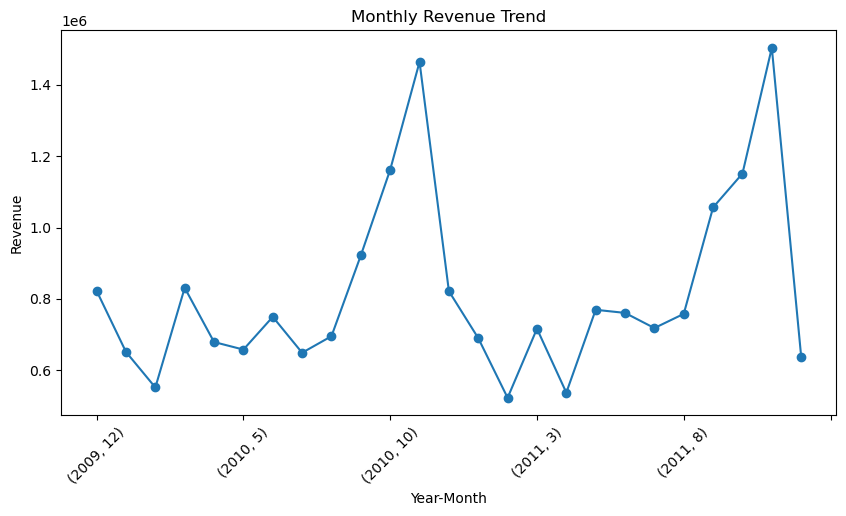

In [42]:
monthly_revenue.plot(kind='line', marker='o', figsize=(10, 5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### 4.3 Top 10 Products by Revenue

In [43]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

top_products

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64

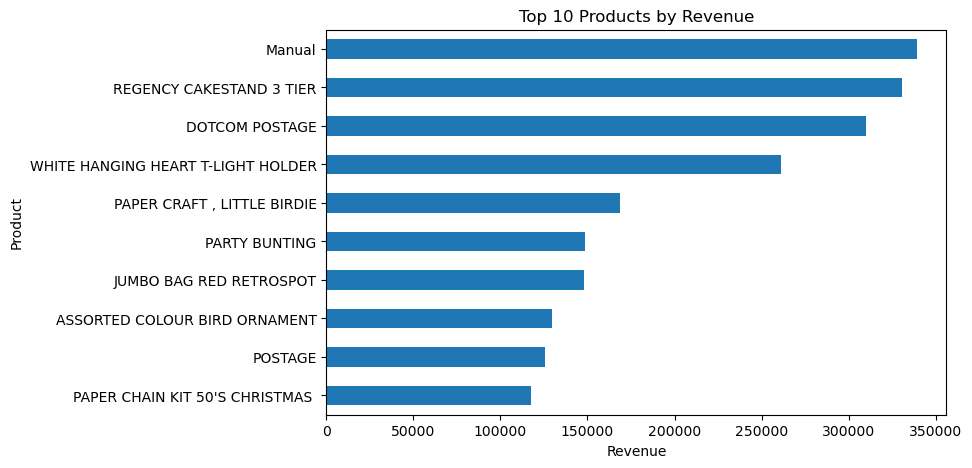

In [44]:
top_products.plot(kind='barh', figsize=(8, 5))

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.show()

### 4.4 Top 10 Customers by Revenue

In [45]:
top_customers = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(10)

top_customers

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

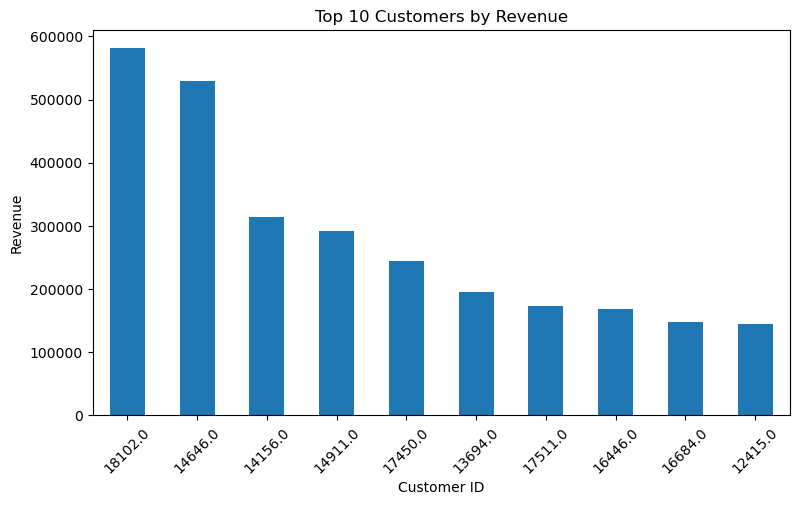

In [46]:
top_customers.plot(kind='bar', figsize=(9, 5))

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### 4.5 Revenue by Country

In [47]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_revenue

Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

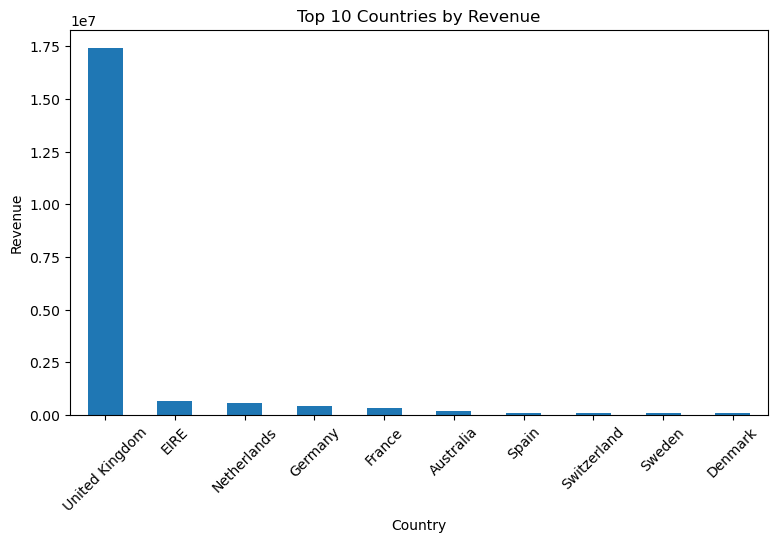

In [48]:
country_revenue.plot(kind='bar', figsize=(9, 5))

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# 5. Export Cleaned Dataset

In [50]:
df.to_csv("../data/processed/ecommerce_cleaned.csv", index=False)

In [51]:
import os

print(os.path.getsize("../data/processed/ecommerce_cleaned.csv"))

105433740
